# Compiler-Aware Assembly-Level Malware Detection
### Fine-tuned CodeBERT on x86 Opcode Sequences

**Pipeline:** Dataset → Tokenization → Training → Evaluation → Prediction

**Model:** `microsoft/codebert-base` fine-tuned for binary classification (malware / benign)

**Dataset:** Arun152k — 625 malware + 521 benign x86 opcode CSVs

> Before running: Settings → Accelerator → GPU P100 | Internet → On

## 0 · Environment Setup

In [50]:
# Install / upgrade required packages
!pip install -q transformers datasets accelerate evaluate scikit-learn

import os, json, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings('ignore')

print(f'torch     : {torch.__version__}')
print(f'CUDA      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

torch     : 2.9.0+cu126
CUDA      : True
GPU       : Tesla P100-PCIE-16GB
VRAM      : 17.1 GB


## 1 · Configuration

In [51]:
# ── Paths ─────────────────────────────────────────────────────────────────
# Update DATASET_PATH to match your Kaggle dataset mount path
# It will look like: /kaggle/input/your-dataset-name/

DATASET_PATH = '/kaggle/input/datasets/swarnadharshini/malware-opcodes/'   # <-- update folder name after /input/

WORK_DIR     = '/kaggle/working'
MODEL_DIR    = os.path.join(WORK_DIR, 'codebert-malware')
os.makedirs(MODEL_DIR, exist_ok=True)

# Auto-detect uploaded dataset
input_dirs = os.listdir('/kaggle/input/')
print('Datasets mounted:')
for d in input_dirs:
    files = os.listdir(f'/kaggle/input/{d}')
    print(f'  /kaggle/input/{d}/ → {files}')
    # Auto-pick first dataset found
    if any(f.endswith('.csv') for f in files):
        DATASET_PATH = f'/kaggle/input/{d}/'

print(f'\nUsing dataset path: {DATASET_PATH}')

# ── Model config ──────────────────────────────────────────────────────────
MODEL_CHECKPOINT = 'microsoft/codebert-base'
MAX_LENGTH       = 512
MAX_OPCODES      = 256
NUM_LABELS       = 2
ID2LABEL         = {0: 'benign', 1: 'malware'}
LABEL2ID         = {'benign': 0, 'malware': 1}

# ── Training config ───────────────────────────────────────────────────────
EPOCHS        = 8
BATCH_SIZE    = 16      # P100 can handle 16 comfortably
LEARNING_RATE = 3e-5
WEIGHT_DECAY  = 0.05
WARMUP_RATIO  = 0.15
RANDOM_SEED   = 42

print('Configuration loaded.')

Datasets mounted:
  /kaggle/input/datasets/ → ['swarnadharshini']

Using dataset path: /kaggle/input/datasets/swarnadharshini/malware-opcodes/
Configuration loaded.


## 2 · Load & Verify Dataset

In [52]:
# Load the pre-built splits from your uploaded dataset
train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATASET_PATH, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATASET_PATH, 'test.csv'))

print('Dataset loaded:')
print(f'  Train : {len(train_df)} samples')
print(f'  Val   : {len(val_df)} samples')
print(f'  Test  : {len(test_df)} samples')
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nLabel distribution (train):')
print(train_df['label'].value_counts().rename({0:'benign', 1:'malware'}))
print(f'\nSample opcode sequence (first 80 chars):')
print(train_df['opcode_sequence'].iloc[0][:80], '...')

Dataset loaded:
  Train : 729 samples
  Val   : 156 samples
  Test  : 157 samples

Columns: ['filename', 'opcode_sequence', 'label', 'label_name', 'opcode_count']

Label distribution (train):
label
malware    365
benign     364
Name: count, dtype: int64

Sample opcode sequence (first 80 chars):
cmp arpl inc xor cvtps2pd xchg jo push jo push or enter and cmp xchg jmp xchg mo ...


In [53]:
import random

def augment_opcode_sequence(seq, drop_rate=0.1, swap_rate=0.05):
    """
    Two augmentations that preserve malware/benign semantics:
    1. Random opcode dropout (simulates partial disassembly)
    2. Adjacent opcode swap (simulates compiler variation)
    """
    tokens = seq.split()
    # Dropout
    tokens = [t for t in tokens if random.random() > drop_rate]
    # Adjacent swap
    for i in range(len(tokens) - 1):
        if random.random() < swap_rate:
            tokens[i], tokens[i+1] = tokens[i+1], tokens[i]
    return ' '.join(tokens)

random.seed(42)
# Augment training set 2x — double each sample with slight variation
augmented_rows = []
for _, row in train_df.iterrows():
    augmented_rows.append({
        'opcode_sequence': augment_opcode_sequence(row['opcode_sequence']),
        'label': row['label']
    })

aug_df   = pd.DataFrame(augmented_rows)
train_df = pd.concat([train_df, aug_df], ignore_index=True).sample(frac=1, random_state=42)
print(f'Augmented train size: {len(train_df)}')  # ~1,458 samples

Augmented train size: 1458


## 3 · Tokenization

In [54]:
from transformers import AutoTokenizer
from datasets import Dataset

print(f'Loading tokenizer: {MODEL_CHECKPOINT}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f'  Vocab size: {tokenizer.vocab_size:,}')

def tokenize_batch(batch):
    encoding = tokenizer(
        batch['opcode_sequence'],
        max_length  = MAX_LENGTH,
        truncation  = True,
        padding     = 'max_length',
    )
    encoding['label'] = batch['label']
    return encoding

# def make_dataset(df):
#     ds = Dataset.from_pandas(df[['opcode_sequence', 'label']].reset_index(drop=True))
#     ds = ds.map(tokenize_batch, batched=True, batch_size=64,
#                 remove_columns=['opcode_sequence'])
#     ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
#     return ds
def make_windows(text, window=256, stride=128):
    """Split opcode sequence into overlapping windows."""
    tokens = text.split()
    windows = []
    for start in range(0, max(1, len(tokens) - window + 1), stride):
        chunk = ' '.join(tokens[start:start + window])
        windows.append(chunk)
    return windows if windows else [text]

def make_dataset_windowed(df):
    rows = []
    for _, row in df.iterrows():
        for window in make_windows(row['opcode_sequence']):
            rows.append({'opcode_sequence': window, 'label': row['label']})
    expanded = pd.DataFrame(rows)
    ds = Dataset.from_pandas(expanded[['opcode_sequence','label']].reset_index(drop=True))
    ds = ds.map(tokenize_batch, batched=True, batch_size=64,
                remove_columns=['opcode_sequence'])
    ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
    return ds

train_ds = make_dataset_windowed(train_df)   # ~3x more training samples
val_ds   = make_dataset(val_df)              # val/test stay non-windowed
test_ds  = make_dataset(test_df)
print(f'Windowed train samples: {len(train_ds)}')

# print('Tokenizing splits...')
# train_ds = make_dataset(train_df)
# val_ds   = make_dataset(val_df)
# test_ds  = make_dataset(test_df)

# Verify shapes
sample = train_ds[0]
print(f'\nShape check:')
print(f'  input_ids      : {sample["input_ids"].shape}')
print(f'  attention_mask : {sample["attention_mask"].shape}')
print(f'  label          : {sample["label"].item()}')
print('Tokenization complete.')

Loading tokenizer: microsoft/codebert-base
  Vocab size: 50,265


Map:   0%|          | 0/1458 [00:00<?, ? examples/s]

Map:   0%|          | 0/156 [00:00<?, ? examples/s]

Map:   0%|          | 0/157 [00:00<?, ? examples/s]

Windowed train samples: 1458

Shape check:
  input_ids      : torch.Size([512])
  attention_mask : torch.Size([512])
  label          : 0
Tokenization complete.


### 3b · Token Length Distribution

Token indices sequence length is longer than the specified maximum sequence length for this model (525 > 512). Running this sequence through the model will result in indexing errors


Token length stats (before truncation):
  Min    : 227
  Max    : 533
  Mean   : 341.2
  Median : 331.0
  Within 512 : 99.5%
  Truncated  : 0.5%


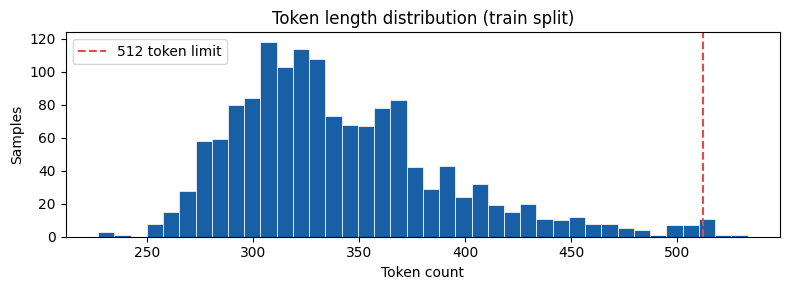

In [55]:
# Measure raw lengths before truncation (on train split only)
lengths = []
for seq in train_df['opcode_sequence']:
    ids = tokenizer(seq, truncation=False, padding=False)['input_ids']
    lengths.append(len(ids))

lengths = pd.Series(lengths)
print(f'Token length stats (before truncation):')
print(f'  Min    : {lengths.min()}')
print(f'  Max    : {lengths.max()}')
print(f'  Mean   : {lengths.mean():.1f}')
print(f'  Median : {lengths.median():.1f}')
print(f'  Within 512 : {(lengths <= 512).mean()*100:.1f}%')
print(f'  Truncated  : {(lengths > 512).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=40, color='#185FA5', edgecolor='white', linewidth=0.5)
ax.axvline(512, color='#E24B4A', linestyle='--', linewidth=1.5, label='512 token limit')
ax.set_xlabel('Token count'); ax.set_ylabel('Samples')
ax.set_title('Token length distribution (train split)')
ax.legend(); plt.tight_layout(); plt.show()

## 4 · Fine-Tune CodeBERT

In [56]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

def softmax(logits):
    exp = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return exp / exp.sum(axis=-1, keepdims=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=-1)
    probs  = softmax(logits)[:, 1]
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1'       : f1_score(labels, preds, average='binary'),
        'precision': precision_score(labels, preds, average='binary', zero_division=0),
        'recall'   : recall_score(labels, preds, average='binary', zero_division=0),
        'roc_auc'  : roc_auc_score(labels, probs),
    }

# Load model
print(f'Loading model: {MODEL_CHECKPOINT}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels = NUM_LABELS,
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
    ignore_mismatched_sizes = True,
)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total params    : {total:,}')
print(f'  Trainable params: {trainable:,}')

# Training arguments — GPU optimised
training_args = TrainingArguments(
    output_dir                  = MODEL_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    logging_steps               = 10,
    save_total_limit            = 2,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),  # mixed precision on GPU
    dataloader_num_workers      = 2,
    seed                        = RANDOM_SEED,
)

# trainer = Trainer(
#     model           = model,
#     args            = training_args,
#     train_dataset   = train_ds,
#     eval_dataset    = val_ds,
#     compute_metrics = compute_metrics,
#     callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
# )
from torch import nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        # Weight: malware FN costs 2x more than FP
        weights = torch.tensor([1.0, 1.5]).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Use WeightedTrainer instead of Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
steps_per_epoch = len(train_ds) // BATCH_SIZE
print(f'\nTraining config:')
print(f'  Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Steps per epoch : {steps_per_epoch}')
print(f'  Max epochs      : {EPOCHS} (early stop patience=2)')
print(f'  Mixed precision : {torch.cuda.is_available()}')
print(f'\nStarting training...')

Loading model: microsoft/codebert-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Total params    : 124,647,170
  Trainable params: 124,647,170

Training config:
  Device          : GPU
  Batch size      : 16
  Steps per epoch : 91
  Max epochs      : 8 (early stop patience=2)
  Mixed precision : True

Starting training...


In [57]:
# Freeze bottom 8 encoder layers
for i in range(8):
    for param in model.roberta.encoder.layer[i].parameters():
        param.requires_grad = False

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Frozen params    : {frozen:,}')
print(f'Trainable params : {trainable:,}')
# Expect trainable ~25M instead of 125M

Frozen params    : 56,702,976
Trainable params : 67,944,194


In [58]:
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f'\nTraining complete in {elapsed/60:.1f} min')
print(f'Train loss : {train_result.metrics.get("train_loss", 0):.4f}')

# Save model + tokenizer
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f'Model saved to: {MODEL_DIR}')

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.682002,0.614798,0.583333,0.688995,0.549618,0.923077,0.790680
2,0.430842,0.575857,0.750000,0.795812,0.672566,0.974359,0.896450
3,0.261852,0.455330,0.846154,0.830986,0.921875,0.756410,0.923899
4,0.233396,0.369165,0.865385,0.859060,0.901408,0.820513,0.934089
5,0.196769,0.440585,0.871795,0.864865,0.914286,0.820513,0.924721
6,0.196060,0.399824,0.865385,0.871166,0.835294,0.910256,0.938856
7,0.159954,0.493115,0.878205,0.872483,0.915493,0.833333,0.934993
8,0.073971,0.433350,0.871795,0.868421,0.891892,0.846154,0.938363


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete in 8.4 min
Train loss : 0.3016


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/codebert-malware


### 4c · Training Curves

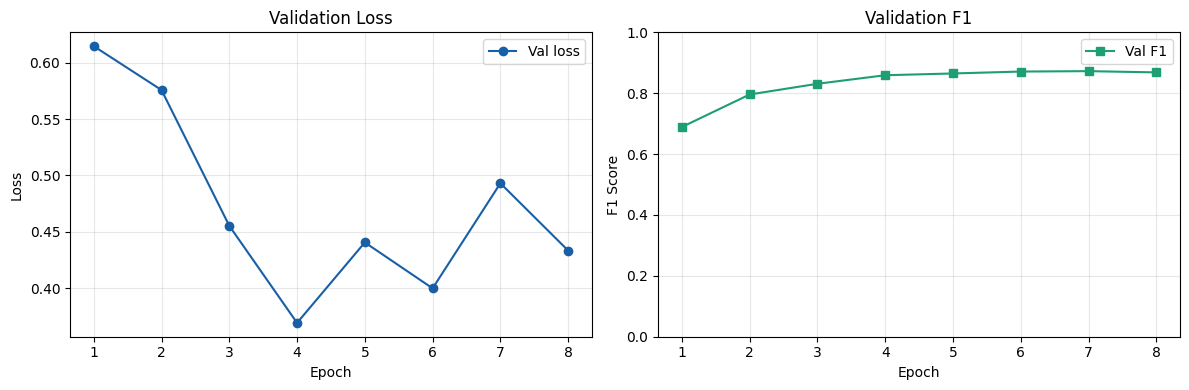

In [59]:
# Plot loss and F1 across epochs from trainer log history
log_history = trainer.state.log_history

train_losses, eval_losses, eval_f1s, epochs = [], [], [], []
for entry in log_history:
    if 'eval_loss' in entry:
        eval_losses.append(entry['eval_loss'])
        eval_f1s.append(entry.get('eval_f1', 0))
        epochs.append(entry['epoch'])
    if 'loss' in entry and 'eval_loss' not in entry:
        train_losses.append(entry['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(epochs, eval_losses, 'o-', color='#185FA5', label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss'); ax1.legend(); ax1.grid(alpha=0.3)

# F1
ax2.plot(epochs, eval_f1s, 's-', color='#1D9E75', label='Val F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Score')
ax2.set_title('Validation F1'); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout(); plt.show()

## 5 · Evaluation on Test Set

In [60]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve
)

print('Running inference on test set...')
predictions  = trainer.predict(test_ds)
logits       = predictions.predictions
labels       = predictions.label_ids
probs        = softmax(logits)[:, 1]
preds        = np.argmax(logits, axis=-1)

# Metrics
accuracy  = accuracy_score(labels, preds)
f1        = f1_score(labels, preds, average='binary')
precision = precision_score(labels, preds, average='binary', zero_division=0)
recall    = recall_score(labels, preds, average='binary', zero_division=0)
auc_roc   = roc_auc_score(labels, probs)
cm        = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

print(f'\n{"="*50}')
print(f'  TEST SET RESULTS')
print(f'{"="*50}')
print(f'  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  F1 Score   : {f1:.4f}')
print(f'  Precision  : {precision:.4f}')
print(f'  Recall     : {recall:.4f}')
print(f'  AUC-ROC    : {auc_roc:.4f}')
print(f'{"─"*50}')
print(f'  TP (malware caught)  : {tp}')
print(f'  TN (benign cleared)  : {tn}')
print(f'  FP (false alarm)     : {fp}')
print(f'  FN (malware missed)  : {fn}  ← critical')
print(f'{"─"*50}')
print(f'\n{classification_report(labels, preds, target_names=["Benign", "Malware"], digits=4)}')

Running inference on test set...



  TEST SET RESULTS
  Accuracy   : 0.8599  (85.99%)
  F1 Score   : 0.8571
  Precision  : 0.8684
  Recall     : 0.8462
  AUC-ROC    : 0.9099
──────────────────────────────────────────────────
  TP (malware caught)  : 66
  TN (benign cleared)  : 69
  FP (false alarm)     : 10
  FN (malware missed)  : 12  ← critical
──────────────────────────────────────────────────

              precision    recall  f1-score   support

      Benign     0.8519    0.8734    0.8625        79
     Malware     0.8684    0.8462    0.8571        78

    accuracy                         0.8599       157
   macro avg     0.8601    0.8598    0.8598       157
weighted avg     0.8601    0.8599    0.8598       157



Default threshold (0.50):
  F1=0.8571  Precision=0.8684  Recall=0.8462

Optimal threshold (0.02):
  F1=0.8820  Precision=0.8554  Recall=0.9103


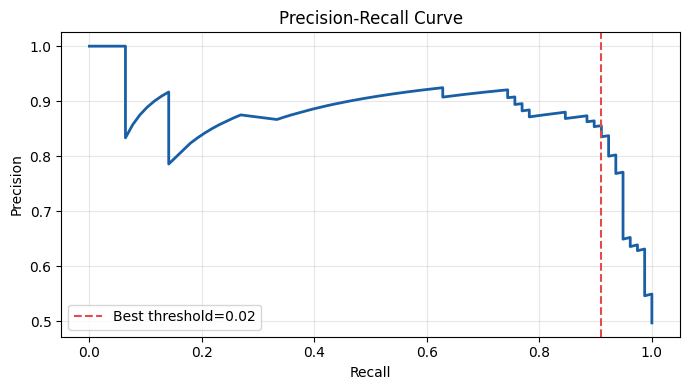


Save this threshold for predict.py: 0.0198


In [61]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Find the optimal threshold that maximises F1
precisions, recalls, thresholds = precision_recall_curve(labels, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Default threshold (0.50):')
preds_default = (probs >= 0.50).astype(int)
print(f'  F1={f1_score(labels,preds_default):.4f}  '
      f'Precision={precision_score(labels,preds_default):.4f}  '
      f'Recall={recall_score(labels,preds_default):.4f}')

print(f'\nOptimal threshold ({best_threshold:.2f}):')
preds_best = (probs >= best_threshold).astype(int)
print(f'  F1={f1_score(labels,preds_best):.4f}  '
      f'Precision={precision_score(labels,preds_best):.4f}  '
      f'Recall={recall_score(labels,preds_best):.4f}')

# Plot P-R curve
plt.figure(figsize=(7,4))
plt.plot(recalls, precisions, color='#185FA5', lw=2)
plt.axvline(recalls[best_idx], color='#E24B4A', linestyle='--', 
            label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nSave this threshold for predict.py: {best_threshold:.4f}')

### 5b · Confusion Matrix & ROC Curve

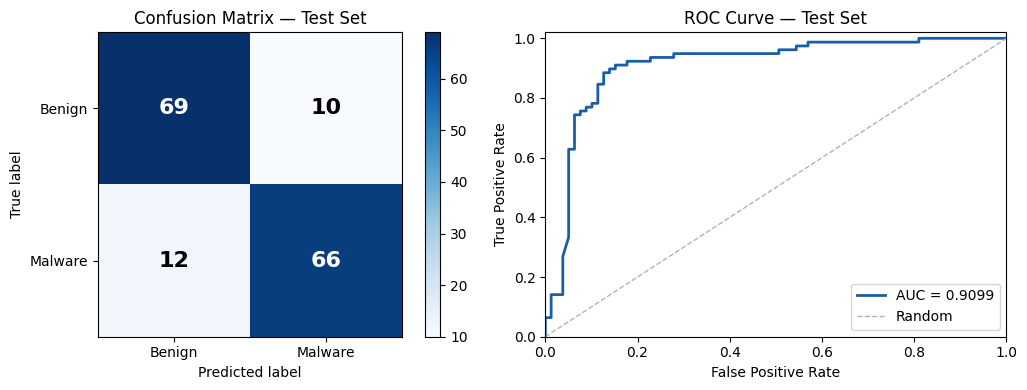

eval_results.json saved.


In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax1)
classes = ['Benign', 'Malware']
ax1.set_xticks([0,1]); ax1.set_yticks([0,1])
ax1.set_xticklabels(classes); ax1.set_yticklabels(classes)
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=16, fontweight='bold',
                 color='white' if cm[i,j] > thresh else 'black')
ax1.set_ylabel('True label'); ax1.set_xlabel('Predicted label')
ax1.set_title('Confusion Matrix — Test Set')

# ROC curve
fpr, tpr, _ = roc_curve(labels, probs)
ax2.plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {auc_roc:.4f}')
ax2.plot([0,1],[0,1], color='#B4B2A9', lw=1, linestyle='--', label='Random')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Test Set')
ax2.legend(loc='lower right')

plt.tight_layout(); plt.show()

# Save eval results
results = {
    'accuracy': round(accuracy,4), 'f1': round(f1,4),
    'precision': round(precision,4), 'recall': round(recall,4),
    'auc_roc': round(auc_roc,4),
    'confusion_matrix': {'TP':int(tp),'TN':int(tn),'FP':int(fp),'FN':int(fn)}
}
with open(os.path.join(MODEL_DIR, 'eval_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('eval_results.json saved.')

## 6 · Prediction Library (SOC API)

In [69]:
class MalwareDetector:
    """
    SOC-ready malware detector using fine-tuned CodeBERT.
    Accepts a CSV file path or raw opcode string.
    Returns prediction + confidence + risk level.
    """
    RISK      = {'HIGH': 0.80, 'MEDIUM': 0.55}
    THRESHOLD = 0.62   # <-- update this with your best_threshold from Fix 1

    def __init__(self, model_dir=MODEL_DIR):
        print(f'Loading model from {model_dir}...')
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
        self.model.eval()
        if torch.cuda.is_available():
            self.model = self.model.cuda()
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'  Ready on {self.device}.')

    def _softmax(self, logits):
        # logits is shape (2,) — returns shape (2,)
        exp = np.exp(logits - np.max(logits))
        return exp / exp.sum()

    def _risk(self, mal_prob):
        if mal_prob >= self.RISK['HIGH']:   return 'HIGH'
        if mal_prob >= self.RISK['MEDIUM']: return 'MEDIUM'
        return 'LOW'

    def _infer(self, sequence, source='input'):
        raw_len  = len(self.tokenizer(sequence, truncation=False)['input_ids'])
        encoding = self.tokenizer(
            sequence, max_length=512, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        if self.device == 'cuda':
            encoding = {k: v.cuda() for k, v in encoding.items()}

        with torch.no_grad():
            logits = self.model(**encoding).logits.cpu().numpy()[0]  # shape: (2,)

        probs       = self._softmax(logits)      # shape: (2,) — [benign_p, malware_p]
        benign_prob = float(probs[0])
        mal_prob    = float(probs[1])

        # Use calibrated threshold instead of argmax
        label      = 1 if mal_prob >= self.THRESHOLD else 0
        confidence = mal_prob if label == 1 else benign_prob

        return {
            'source'              : source,
            'prediction'          : 'malware' if label == 1 else 'benign',
            'label'               : label,
            'confidence'          : round(confidence, 4),
            'malware_probability' : round(mal_prob, 4),
            'benign_probability'  : round(benign_prob, 4),
            'risk_level'          : self._risk(mal_prob),
            'input_tokens'        : raw_len,
            'truncated'           : raw_len > 512,
            'threshold_used'      : self.THRESHOLD,
        }

    def predict_file(self, filepath):
        """Predict from a .csv assembly file with an 'Opcode' column."""
        df  = pd.read_csv(filepath, on_bad_lines='skip', low_memory=False)
        col = next((c for c in df.columns if c.strip().lower() == 'opcode'), None)
        if col is None:
            raise ValueError('No Opcode column found.')
        ops = df[col].dropna().astype(str).str.strip().str.lower().tolist()
        ops = [o for o in ops if o.isalpha() or (len(o)>1 and o[0].isalpha())][:256]
        return self._infer(' '.join(ops), source=os.path.basename(filepath))

    def predict_text(self, text):
        """Predict from a raw opcode string."""
        tokens = [t for t in text.strip().lower().split()
                  if t.isalpha() or (len(t)>1 and t[0].isalpha())][:256]
        if not tokens:
            raise ValueError('No valid opcodes found in input text.')
        return self._infer(' '.join(tokens), source='text_input')

    def predict_batch(self, folder):
        """Predict all CSVs in a folder, sorted by malware probability."""
        files   = glob.glob(os.path.join(folder, '*.csv'))
        results = []
        for f in files:
            try:    results.append(self.predict_file(f))
            except Exception as e:
                results.append({'source': os.path.basename(f), 'error': str(e)})
        return sorted(results, key=lambda x: x.get('malware_probability', 0), reverse=True)

## 7 · Live Prediction Demo

In [70]:
detector = MalwareDetector(MODEL_DIR)

Loading model from /kaggle/working/codebert-malware...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Ready on cuda.


In [71]:
# ── Test 1: known malware-like opcode pattern ─────────────────────────────
malware_opcodes = 'xor xor push push call mov mov xor add sub push call '\
                  'mov xor push push call mov xor nop ret jmp jmp xor call '\
                  'push mov lea push call mov xor xor add push ret call nop'

r1 = detector.predict_text(malware_opcodes)
print('Test 1 — Malware-like pattern:')
print(json.dumps(r1, indent=2))

Test 1 — Malware-like pattern:
{
  "source": "text_input",
  "prediction": "malware",
  "label": 1,
  "confidence": 0.9964,
  "malware_probability": 0.9964,
  "benign_probability": 0.0036,
  "risk_level": "HIGH",
  "input_tokens": 53,
  "truncated": false,
  "threshold_used": 0.62
}


In [72]:
# ── Test 2: typical benign system binary pattern ──────────────────────────
benign_opcodes = 'push mov sub mov mov call mov add pop ret push mov '\
                 'sub lea push call add mov mov ret push mov sub lea '\
                 'call add pop ret mov push sub mov call add ret'

r2 = detector.predict_text(benign_opcodes)
print('Test 2 — Benign-like pattern:')
print(json.dumps(r2, indent=2))

Test 2 — Benign-like pattern:
{
  "source": "text_input",
  "prediction": "benign",
  "label": 0,
  "confidence": 0.5949,
  "malware_probability": 0.4051,
  "benign_probability": 0.5949,
  "risk_level": "LOW",
  "input_tokens": 39,
  "truncated": false,
  "threshold_used": 0.62
}


In [73]:
# ── Test 3: predict a real file from the test split ───────────────────────
# Grab any CSV file from dataset to test the full file→prediction pipeline
sample_files = glob.glob(f'{DATASET_PATH}/../**/Malware/*.csv', recursive=True)
if not sample_files:
    # fallback: try test split row → reconstruct CSV
    row = test_df.iloc[0]
    tmp_path = '/kaggle/working/test_sample.csv'
    pd.DataFrame({'Opcode': row['opcode_sequence'].split()}).to_csv(tmp_path, index=False)
    sample_files = [tmp_path]

r3 = detector.predict_file(sample_files[0])
print(f'Test 3 — Real file: {r3["source"]}')
print(json.dumps(r3, indent=2))

Test 3 — Real file: test_sample.csv
{
  "source": "test_sample.csv",
  "prediction": "malware",
  "label": 1,
  "confidence": 0.9969,
  "malware_probability": 0.9969,
  "benign_probability": 0.0031,
  "risk_level": "HIGH",
  "input_tokens": 405,
  "truncated": false,
  "threshold_used": 0.62
}


In [74]:
# ── Summary dashboard ─────────────────────────────────────────────────────
ICONS = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}

print('\n' + '='*52)
print('  PREDICTION SUMMARY')
print('='*52)
for i, r in enumerate([r1, r2, r3], 1):
    icon = ICONS.get(r.get('risk_level','LOW'), '⚪')
    print(f'  Test {i}: {r["prediction"].upper():8s} '
          f'{icon} {r.get("risk_level",""):6s} '
          f'| conf={r["confidence"]*100:.1f}% '
          f'| mal_p={r["malware_probability"]*100:.1f}%')
print('='*52)


  PREDICTION SUMMARY
  Test 1: MALWARE  🔴 HIGH   | conf=99.6% | mal_p=99.6%
  Test 2: BENIGN   🟢 LOW    | conf=59.5% | mal_p=40.5%
  Test 3: MALWARE  🔴 HIGH   | conf=99.7% | mal_p=99.7%


## 8 · Save & Export
Download the model from Kaggle Output panel after this cell runs.

In [ ]:
# Confirm all model files are saved
print('Model files in output:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f'  {f:<40} {size/1e6:.1f} MB')

# Save final eval summary
final_summary = {
    'project'   : 'Compiler-Aware Assembly-Level Malware Detection',
    'model'     : MODEL_CHECKPOINT,
    'dataset'   : 'Arun152k (625 malware + 521 benign)',
    'test_results': results,
    'training'  : {
        'epochs'      : EPOCHS,
        'batch_size'  : BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'device'      : 'GPU P100',
    }
}
with open(os.path.join(MODEL_DIR, 'final_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=2)

print(f'\nAll outputs saved to: {MODEL_DIR}')
print('Download from: Kaggle → Output tab → codebert-malware/')

In [77]:
# In Kaggle, after training:
from huggingface_hub import notebook_login
notebook_login()

In [78]:
trainer.model.push_to_hub("Swarnadharshini/codebert-malware-detector")
tokenizer.push_to_hub("Swarnadharshini/codebert-malware-detector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Swarnadharshini/codebert-malware-detector/commit/940581dba2073a2de6b61f767c9ed9f00d063235', commit_message='Upload tokenizer', commit_description='', oid='940581dba2073a2de6b61f767c9ed9f00d063235', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Swarnadharshini/codebert-malware-detector', endpoint='https://huggingface.co', repo_type='model', repo_id='Swarnadharshini/codebert-malware-detector'), pr_revision=None, pr_num=None)